## STAGE 1: RAW DATASETS EXPLORATION
 
**Objectives:**
1. Analyze dataset sizes and assess **Class Imbalance**.
2. Investigate the **physical attributes** of images (Dimensions, Aspect Ratio, Outliers).
3. Evaluate **visual properties** (Brightness, Contrast) to inspect source image qualities.
4. Compare emotion display differences between laboratory-controlled environments (CK+) and in-the-wild settings (RAF-DB, FER-2013).

### 0. Environment Setup & Initialization


In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm # For tracking data scanning progress
import warnings
warnings.filterwarnings('ignore') # Suppress unnecessary warning outputs

In [2]:
# Publication-ready seaborn plot styling
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({
    'font.size': 11, 
    'figure.figsize': (12, 7),
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
    'legend.fontsize': 11
})

In [3]:
# Define root and dataset directories
PROJECT_ROOT = Path(os.getcwd()).resolve().parents[0]
PREPROCESSED_DIR = PROJECT_ROOT / "data" / "preprocessed"

In [4]:
# Standardized label mapping from the Data Format phase
LABEL_MAPPING = {
    'anger': 'anger', 'happiness': 'happiness', 'neutral': 'neutral', 'sadness': 'sadness',
    'angry': 'anger', 'happy': 'happiness', 'sad': 'sadness', # Normalization mapping specifically for FER-2013
}
TARGET_LABELS = ['anger', 'happiness', 'neutral', 'sadness']


### 1.1 Metadata Extraction
Scan the dataset directories to compile filepaths and labels in memory. Actual pixel read operations are sampled later to optimize memory usage.


In [5]:
records = []
image_paths = list(PREPROCESSED_DIR.rglob('*.*'))

In [6]:
# Filter for valid image formats
valid_extensions = {'.jpg', '.jpeg', '.png'}
image_paths = [p for p in image_paths if p.suffix.lower() in valid_extensions]

print("Analyzing directory structures...")
for img_path in tqdm(image_paths, desc="Parsing Metadata"):
    parent_name = img_path.parent.name.lower()
    if parent_name in LABEL_MAPPING:
        std_label = LABEL_MAPPING[parent_name]
        try:
            dataset_source = img_path.relative_to(PREPROCESSED_DIR).parts[0]
            records.append(
                {
                    "filepath": str(img_path),
                    "filename": img_path.name,
                    "label": std_label,
                    "dataset": dataset_source
                }
            )
        except ValueError:
            continue

df_source = pd.DataFrame(records)
print(f"\n✅ Successfully initialized DataFrame with {len(df_source):,} records.")
display(df_source.head(3))
display(df_source.tail(3))

Analyzing directory structures...


Parsing Metadata: 100%|██████████| 39440/39440 [00:00<00:00, 116212.89it/s]


✅ Successfully initialized DataFrame with 39,440 records.


,filepath,filename,label,dataset
0,/Users/anhnn/Documents/lectures/mentor-fptu/su...,S095_010_00000014.png,sadness,CK+
1,/Users/anhnn/Documents/lectures/mentor-fptu/su...,S115_004_00000017.png,sadness,CK+
2,/Users/anhnn/Documents/lectures/mentor-fptu/su...,S137_005_00000027.png,sadness,CK+


,filepath,filename,label,dataset
39437,/Users/anhnn/Documents/lectures/mentor-fptu/su...,train_07770_aligned.jpg,anger,raf-db
39438,/Users/anhnn/Documents/lectures/mentor-fptu/su...,train_04031_aligned.jpg,anger,raf-db
39439,/Users/anhnn/Documents/lectures/mentor-fptu/su...,train_03038_aligned.jpg,anger,raf-db


### 1.2 Dataset Class Distribution & Imbalance Analysis
Evaluate absolute sample counts and relative percentages to quantify skew and bias in each raw dataset.

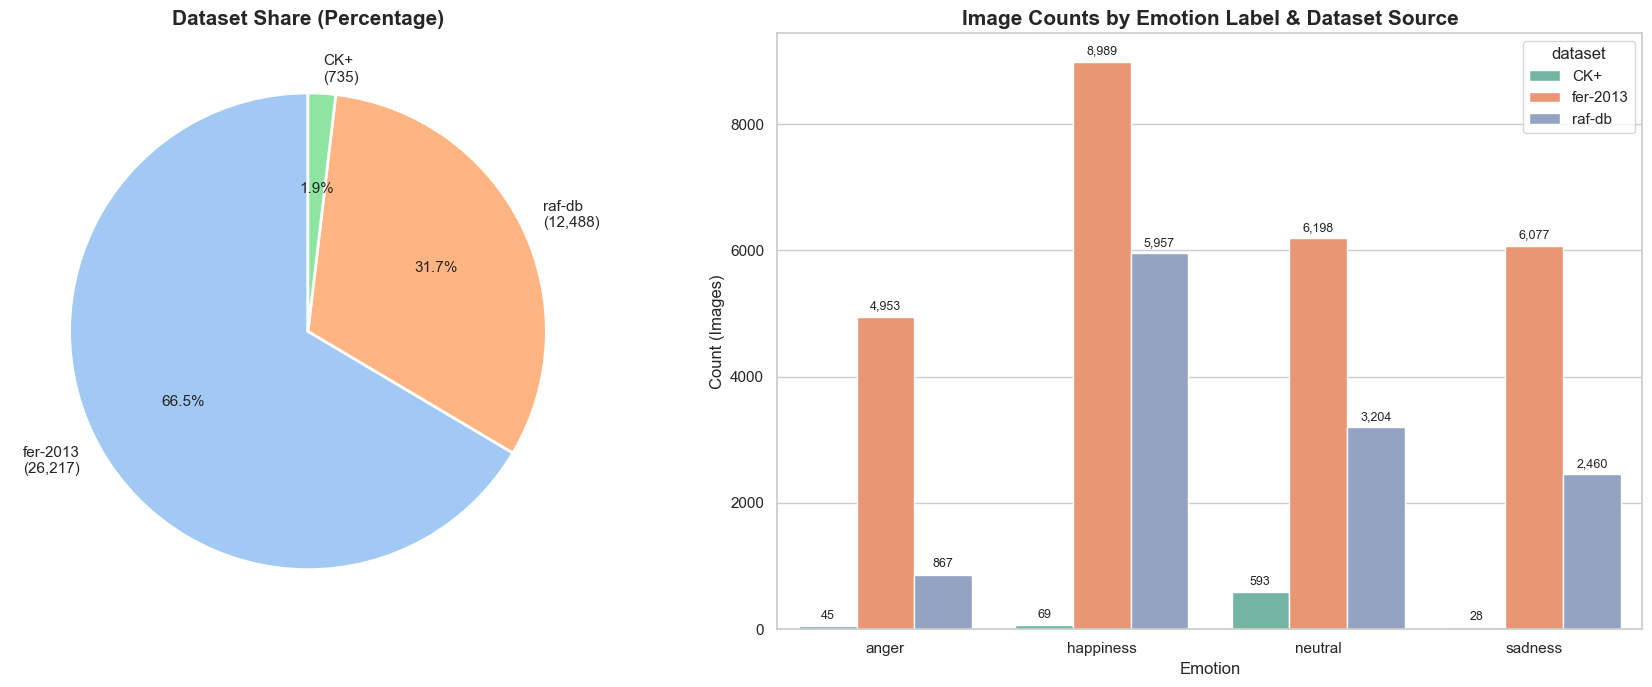

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# 1. Pie Chart: Overall dataset breakdown
dataset_counts = df_source['dataset'].value_counts()
axes[0].pie(
    dataset_counts, 
    labels=[f"{idx}\n({val:,})" for idx, val in dataset_counts.items()], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=sns.color_palette("pastel"),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Dataset Share (Percentage)')

# 2. Countplot: Class distributions within each dataset
sns.countplot(data=df_source, x='label', hue='dataset', order=TARGET_LABELS, ax=axes[1])
axes[1].set_title('Image Counts by Emotion Label & Dataset Source')
axes[1].set_xlabel('Emotion')
axes[1].set_ylabel('Count (Images)')

# Add count labels on top of columns
for p in axes[1].patches:
    height = p.get_height()
    if not np.isnan(height) and height > 0:
        axes[1].annotate(f'{int(height):,}', (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

**Observations:**
-   **FER-2013 dominates in volume:** This dataset accounts for **66.5%** of the entire data pool (over 26,000 images). Without balancing strategies, any neural network would become heavily biased toward FER-2013's lower resolution, noisy style.
-   **"Happiness" is the most frequent label:** In both FER-2013 and RAF-DB, Happiness counts are disproportionately high (nearly 9,000 in FER and 6,000 in RAF). This represents a natural bias in real-world facial expression capture.
-   **Extreme scarcity in CK+:** CK+ contributes only **1.9%** of the total samples. Furthermore, it is mostly concentrated on "Neutral" (593 images). Scarcity in negative emotions ("Anger", "Sadness") means its role in learning these classes is negligible without oversampling.

#### Crosstab Analysis (Relative Proportions within Datasets)
The heatmap below illustrates the internal distribution: *"Within a specific dataset X, what percentage does emotion Y represent?"*

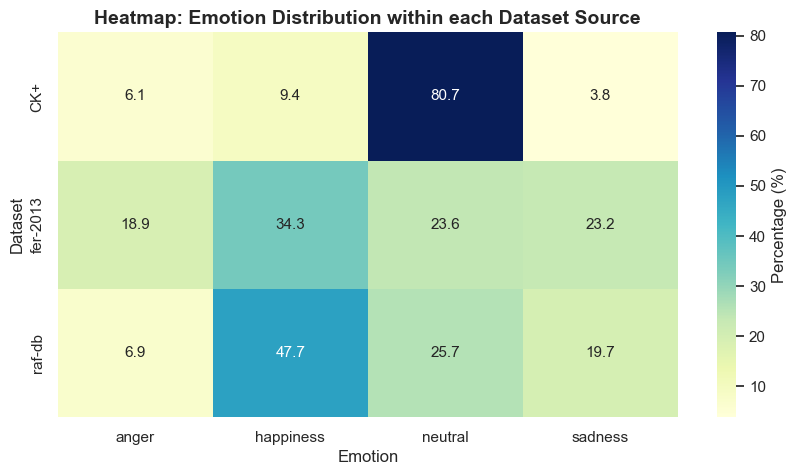

In [8]:
# Calculate percentage normalized across rows
crosstab_percent = pd.crosstab(df_source['dataset'], df_source['label'], normalize='index') * 100

plt.figure(figsize=(10, 5))
sns.heatmap(crosstab_percent, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Percentage (%)'})
plt.title('Heatmap: Emotion Distribution within each Dataset Source', fontsize=14)
plt.ylabel('Dataset')
plt.xlabel('Emotion')
plt.show()

**Observations on the Heatmap (Internal Proportions):**
-   **Severe class imbalance in CK+:** The `neutral` label dominates with **80.7%** of the dataset. Negative emotions like anger or sadness are below 10%, highlighting a severe lack of class diversity.
-   **"Happiness" dominates in-the-wild datasets:** In both wild datasets, `happiness` maintains the highest share (**47.7%** in RAF-DB, **34.3%** in FER-2013). This reflects the social bias where people are more likely to smile in photographs.
-   **"Anger" is universally underrepresented:** Across all datasets, `anger` remains extremely low (only **6-7%** in CK+ and RAF-DB). It will be the most difficult emotion for models to learn without oversampling.
-   **FER-2013 shows the most balanced internal distribution:** Although Happiness is still dominant, the other three classes are distributed relatively evenly (ranging from **18.9% to 23.6%**), making it the most balanced raw dataset source in our pool.

### 1.3 Spatial Dimensionality & Aspect Ratio Analysis
Investigate physical image dimensions across all samples to formulate the resizing strategy.


In [9]:
print(f"Analyzing image shapes for all {len(df_source):,} images (this may take a few minutes depending on disk speed)...")

# Initialize lists to store metrics
widths = []
heights = []
channels = []
aspect_ratios = []

# Iterate through all files in df_source
for _, row in tqdm(df_source.iterrows(), total=len(df_source), desc="Reading Shapes"):
    img = cv2.imread(row['filepath'])
    if img is not None:
        h, w, c = img.shape
        widths.append(w)
        heights.append(h)
        channels.append(c)
        aspect_ratios.append(w / h if h > 0 else 0)
    else:
        # If read fails (corrupt file)
        widths.append(0)
        heights.append(0)
        channels.append(0)
        aspect_ratios.append(0)

# Assign directly as new columns to prevent index misalignment
df_meta = df_source.copy()
df_meta['width'] = widths
df_meta['height'] = heights
df_meta['channels'] = channels
df_meta['aspect_ratio'] = aspect_ratios

# Filter out corrupt records
df_meta = df_meta[df_meta['width'] > 0]

print(f"Analysis complete for {len(df_meta):,} valid images!")

# Display physical image summaries
display(df_meta.groupby('dataset')[['width', 'height', 'aspect_ratio']].describe().round(2))

Analyzing image shapes for all 39,440 images (this may take a few minutes depending on disk speed)...


Reading Shapes: 100%|██████████| 39440/39440 [00:13<00:00, 2907.56it/s]


Analysis complete for 39,440 valid images!


width                                                     height  \
            count    mean    std    min    25%    50%    75%    max    count   
dataset                                                                        
CK+         735.0  643.16  15.58  640.0  640.0  640.0  640.0  720.0    735.0   
fer-2013  26217.0   48.00   0.00   48.0   48.0   48.0   48.0   48.0  26217.0   
raf-db    12488.0  100.00   0.00  100.0  100.0  100.0  100.0  100.0  12488.0   

                  ...               aspect_ratio                          \
            mean  ...    75%    max        count  mean   std   min   25%   
dataset           ...                                                      
CK+       489.31  ...  490.0  490.0        735.0  1.31  0.04  1.31  1.31   
fer-2013   48.00  ...   48.0   48.0      26217.0  1.00  0.00  1.00  1.00   
raf-db    100.00  ...  100.0  100.0      12488.0  1.00  0.00  1.00  1.00   

                           
           50%   75%  max  
dataset                    
CK+       1.31  1.31  1.5  
fer-2013  1.00  1.00  1.0  
raf-db    1.00  1.00  1.0  

[3 rows x 24 columns]

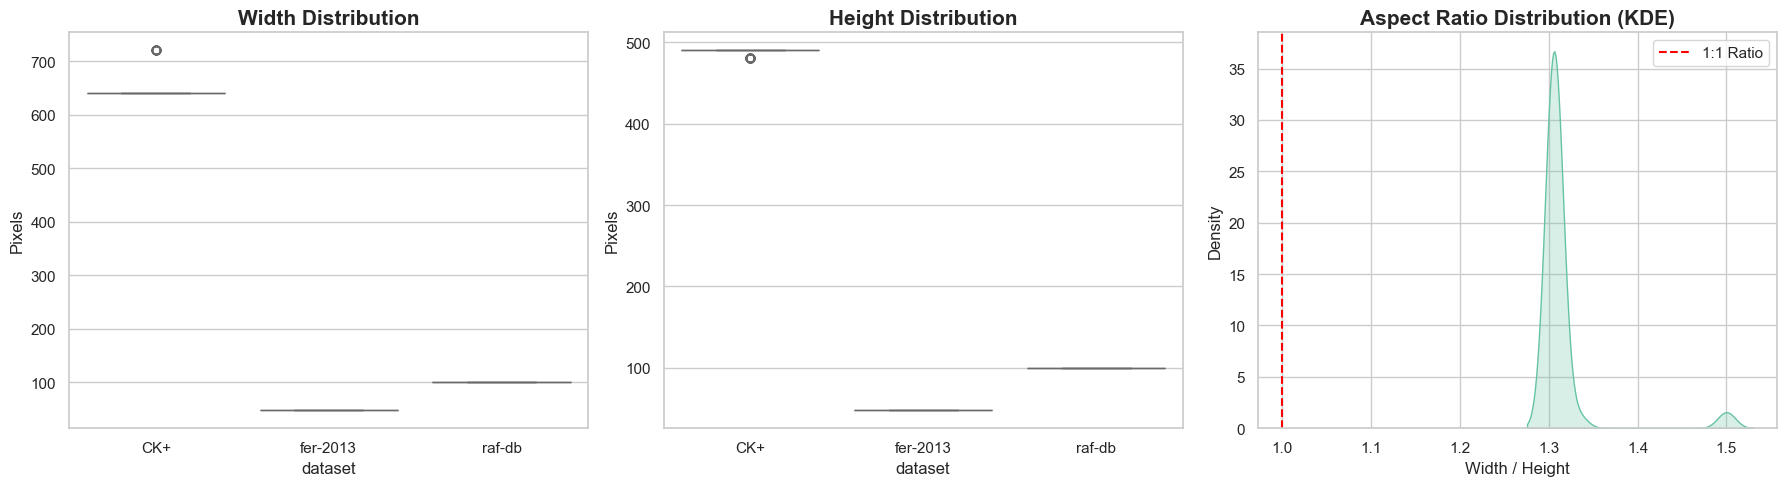

In [10]:
# Visualize dimensions using Boxplots and KDE for Aspect Ratio
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Width Boxplot
sns.boxplot(data=df_meta, x='dataset', y='width', ax=axes[0], palette="Set3")
axes[0].set_title('Width Distribution')
axes[0].set_ylabel('Pixels')

# Height Boxplot
sns.boxplot(data=df_meta, x='dataset', y='height', ax=axes[1], palette="Set3")
axes[1].set_title('Height Distribution')
axes[1].set_ylabel('Pixels')

# Aspect Ratio KDE
sns.kdeplot(data=df_meta, x='aspect_ratio', hue='dataset', ax=axes[2], fill=True, common_norm=False)
axes[2].axvline(1.0, color='red', linestyle='--', label='1:1 Ratio')
axes[2].set_title('Aspect Ratio Distribution (KDE)')
axes[2].set_xlabel('Width / Height')
axes[2].legend()

plt.tight_layout()
plt.show()

**Observations:**
-   **Resolution uniformity in FER-2013 and RAF-DB:** Width and height distribution metrics are completely flat for these two. `fer-2013` samples are uniformly **48x48**, while `raf-db` samples are cropped to **100x100**. Both are perfect squares.
-   **CK+ high resolution:** `CK+` features significantly larger dimensions (mostly around **640x490** pixels) with a few outlier samples exceeding 700px in width.
-   **Image distortion risk for CK+:** The Aspect Ratio plot shows CK+ images are rectangular with a peak ratio around **~1.3** (deviating from the 1:1 square ratio). Compressing them to a square format (e.g. 224x224) introduces slight squeezing. However, in facial emotion recognition, this minor aspect-ratio skew typically does not obscure core micro-expressions.

### 1.4 Cross-Dataset Visual Comparison Matrix
Construct an image grid where rows represent the 4 target emotions and columns represent the 3 source datasets. This enables a direct qualitative comparison of expression characteristics across different domains.


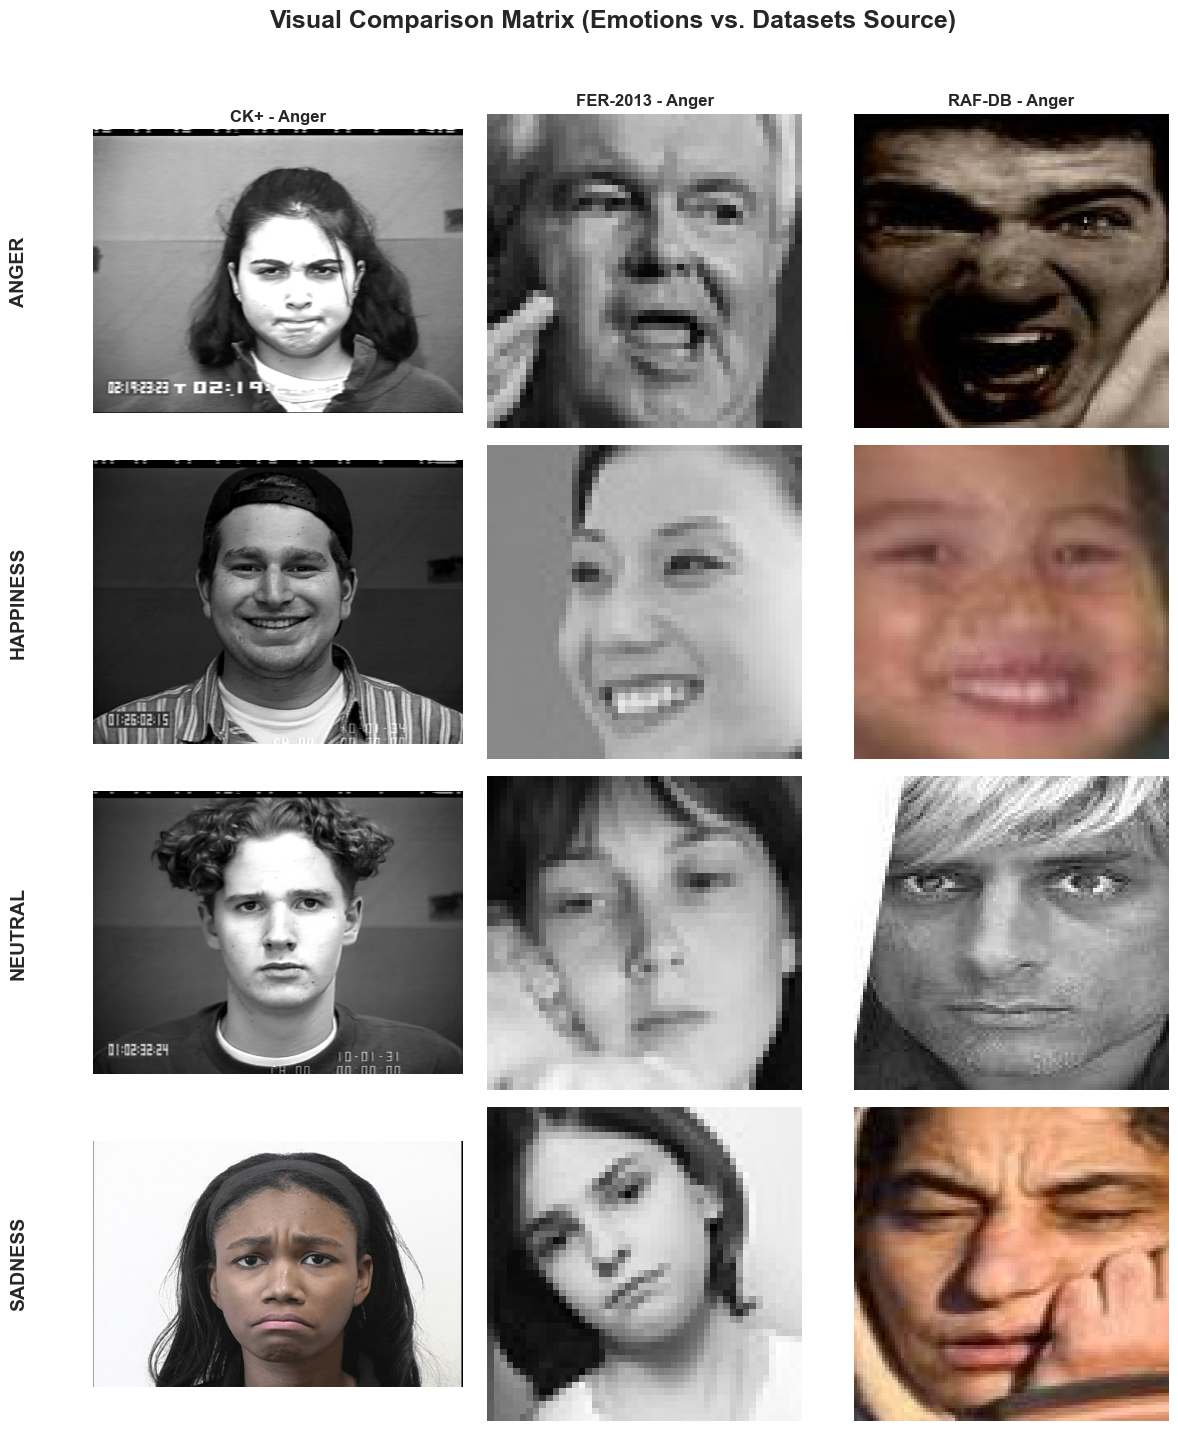

In [11]:
datasets_list = df_source['dataset'].unique()
fig, axes = plt.subplots(len(TARGET_LABELS), len(datasets_list), figsize=(12, 14))
fig.suptitle('Visual Comparison Matrix (Emotions vs. Datasets Source)', fontsize=18, fontweight='bold', y=1.02)

for i, label in enumerate(TARGET_LABELS):
    for j, dataset in enumerate(datasets_list):
        # Draw 1 random sample
        sample = df_source[(df_source['label'] == label) & (df_source['dataset'] == dataset)].sample(1, random_state=123)
        ax = axes[i, j]
        
        if not sample.empty:
            img_path = sample.iloc[0]['filepath']
            img = cv2.imread(img_path)
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img_rgb)
            ax.set_title(f"{dataset.upper()} - {label.capitalize()}" if i == 0 else "", fontsize=12)
        
        ax.axis('off')
        
        # Add vertical row label (Y-label)
        if j == 0:
            ax.text(-0.2, 0.5, label.upper(), transform=ax.transAxes, 
                    fontsize=14, fontweight='bold', va='center', ha='center', rotation=90)

plt.tight_layout()
plt.show()

**Observations:**
-   **CK+:** Grayscale images, plain background, stable lighting, and direct frontal head poses. Expressions are highly exaggerated and clean, although timecode stamps are present on some frames.
-   **FER-2013:** Characterized by pixelated, low-resolution 48x48 crops. This source trains models to handle low-fidelity, blurred real-world inputs.
-   **RAF-DB:** Highly diverse. Color images featuring complex backgrounds, head tilts, variable lighting conditions, and partial occlusions (e.g. glasses, hands).
-   CK+ teaches the model pristine facial anatomy, FER-2013 develops robustness to low-res noise, and RAF-DB bridges the gap to natural real-world webcam inference.

### 1.5 Brightness & Contrast Analysis
Compute mean pixel intensity (Brightness indicator) and standard deviation (Contrast indicator) for each image in grayscale space.


In [12]:
print("Calculating pixel-level statistics...")

brightness = []
contrast = []

for _, row in tqdm(df_meta.iterrows(), total=len(df_meta)):
    # Read in grayscale
    gray_img = cv2.imread(row['filepath'], cv2.IMREAD_GRAYSCALE)
    if gray_img is not None:
        brightness.append(np.mean(gray_img))   # Mean = Brightness
        contrast.append(np.std(gray_img))      # Std = Contrast
    else:
        brightness.append(0)
        contrast.append(0)

df_meta['brightness'] = brightness
df_meta['contrast'] = contrast

Calculating pixel-level statistics...


100%|██████████| 39440/39440 [00:13<00:00, 2944.58it/s]


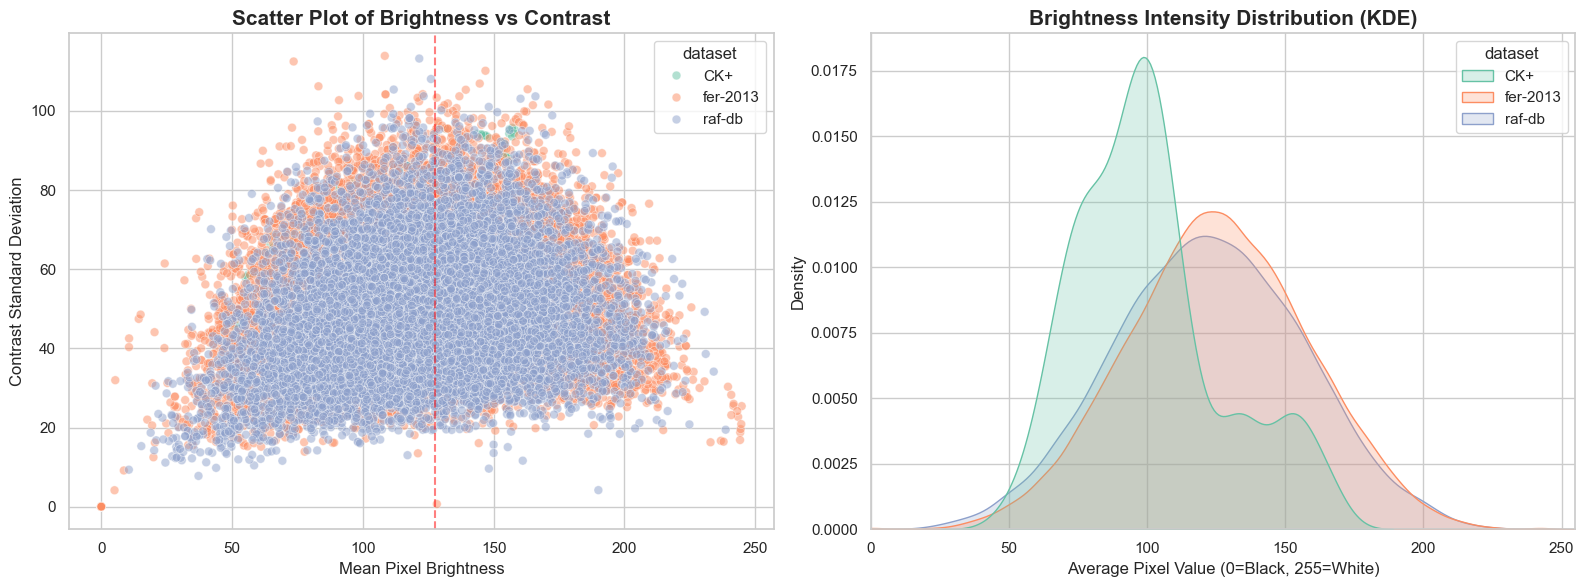

In [13]:
# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Brightness vs Contrast
sns.scatterplot(data=df_meta, x='brightness', y='contrast', hue='dataset', alpha=0.5, s=40, ax=axes[0])
axes[0].set_title('Scatter Plot of Brightness vs Contrast', fontweight='bold')
axes[0].set_xlabel('Mean Pixel Brightness')
axes[0].set_ylabel('Contrast Standard Deviation')
axes[0].axvline(127.5, color='red', linestyle='--', alpha=0.5) # Divider line (Dark vs Light midpoint)

# KDE Plot: Overall brightness distributions
sns.kdeplot(data=df_meta, x='brightness', hue='dataset', fill=True, common_norm=False, ax=axes[1])
axes[1].set_title('Brightness Intensity Distribution (KDE)', fontweight='bold')
axes[1].set_xlabel('Average Pixel Value (0=Black, 255=White)')
axes[1].set_xlim(0, 255)

plt.tight_layout()
plt.show()

**Observations:**
-   **CK+ is significantly darker (Left-Skewed):** In the KDE density plot, CK+'s curve peaks at a lower range (80-100). This reflects the plain black background of CK+ which pulls the overall mean brightness down.
-   **Illumination similarity in wild datasets:** RAF-DB and FER-2013 share nearly identical bell-shaped distributions, centering naturally around the mid-tone range (120-130).
-   **The Contrast Arch:** The scatter plot illustrates a dome-shaped boundary. This visualizes a key principle: extremely dark (near 0) or overexposed (near 255) images suffer from severe detail loss (low contrast). Optimal image details reside in the mid-tone region (around the 127.5 red dashed line).
-   **Significance of Normalization:** The illumination deviation in CK+ reinforces the necessity of normalization (`/ 255.0` or equivalent scaling) in our DataLoader. Feeding raw range pixel values directly risks biasing neural nets toward environmental brightness shifts rather than facial expressions.